# Customer Churn Prediction

## 1. Import Libraries

In [126]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [127]:
# Load the dataset
df = pd.read_csv("data/Telco-Customer-Churn.csv")



# 3. Data Preprocessing

## 3.1 Dataset Overview

In [128]:
# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [129]:
# Check dataset dimensions
df.shape

(7043, 21)

In [130]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 3.2 Missing Values

In [131]:
# Check for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3.3 Duplicate Records

In [132]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

### 3.4 Data Cleaning

In [133]:
# Convert TotalCharges to numeric datatype

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [134]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [135]:
# Remove rows containing missing values
df.dropna(inplace=True)

In [136]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [137]:
# Drop customerID as it does not contribute to the prediction
df.drop('customerID', axis=1, inplace=True)

### 3.5 Encoding Categorical Features

In [138]:
# Convert categorical features to numerical features using one-hot encoding
df = pd.get_dummies(df, drop_first=True, dtype=int)

In [139]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [140]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int64  
 5   Partner_Yes                            7032 non-null   int64  
 6   Dependents_Yes                         7032 non-null   int64  
 7   PhoneService_Yes                       7032 non-null   int64  
 8   MultipleLines_No phone service         7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetService_No  

In [141]:
# Convert boolean columns to integer datatype
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [142]:
df.info()

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7032 non-null   int64  
 1   tenure                                 7032 non-null   int64  
 2   MonthlyCharges                         7032 non-null   float64
 3   TotalCharges                           7032 non-null   float64
 4   gender_Male                            7032 non-null   int64  
 5   Partner_Yes                            7032 non-null   int64  
 6   Dependents_Yes                         7032 non-null   int64  
 7   PhoneService_Yes                       7032 non-null   int64  
 8   MultipleLines_No phone service         7032 non-null   int64  
 9   MultipleLines_Yes                      7032 non-null   int64  
 10  InternetService_Fiber optic            7032 non-null   int64  
 11  InternetService_No  

In [143]:
df.shape

(7032, 31)

In [144]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

In [145]:
# Check for missing values
df.isnull().sum()


SeniorCitizen                            0
tenure                                   0
MonthlyCharges                           0
TotalCharges                             0
gender_Male                              0
Partner_Yes                              0
Dependents_Yes                           0
PhoneService_Yes                         0
MultipleLines_No phone service           0
MultipleLines_Yes                        0
InternetService_Fiber optic              0
InternetService_No                       0
OnlineSecurity_No internet service       0
OnlineSecurity_Yes                       0
OnlineBackup_No internet service         0
OnlineBackup_Yes                         0
DeviceProtection_No internet service     0
DeviceProtection_Yes                     0
TechSupport_No internet service          0
TechSupport_Yes                          0
StreamingTV_No internet service          0
StreamingTV_Yes                          0
StreamingMovies_No internet service      0
StreamingMo

In [146]:

# Check duplicate rows
df.duplicated().sum()

np.int64(0)

In [147]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [148]:
df.shape

(7010, 31)

### 3.6 Save Cleaned Dataset

In [149]:
# Save the cleaned dataset
df.to_csv(
    "data/Telco-Customer-Churn-Cleaned.csv",
    index=False
)

## 4. Exploratory Data Analysis

### 4.1 What percentage of customers have churned?

In [150]:
# Calculate churn percentage
churn_percentage = df["Churn_Yes"].value_counts(normalize=True) * 100

# Display percentages
print(f"No Churn Percentage: {churn_percentage[0]:.2f}%")
print(f"Churn Percentage: {churn_percentage[1]:.2f}%")

No Churn Percentage: 73.51%
Churn Percentage: 26.49%


### 4.2 Which contract type has the highest churn?

In [152]:
# Display contract-related columns
df.columns[df.columns.str.contains('Contract')]

Index(['Contract_One year', 'Contract_Two year'], dtype='str')

C:\Users\Aizen Yagami\AppData\Local\Temp\ipykernel_5812\2300646497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


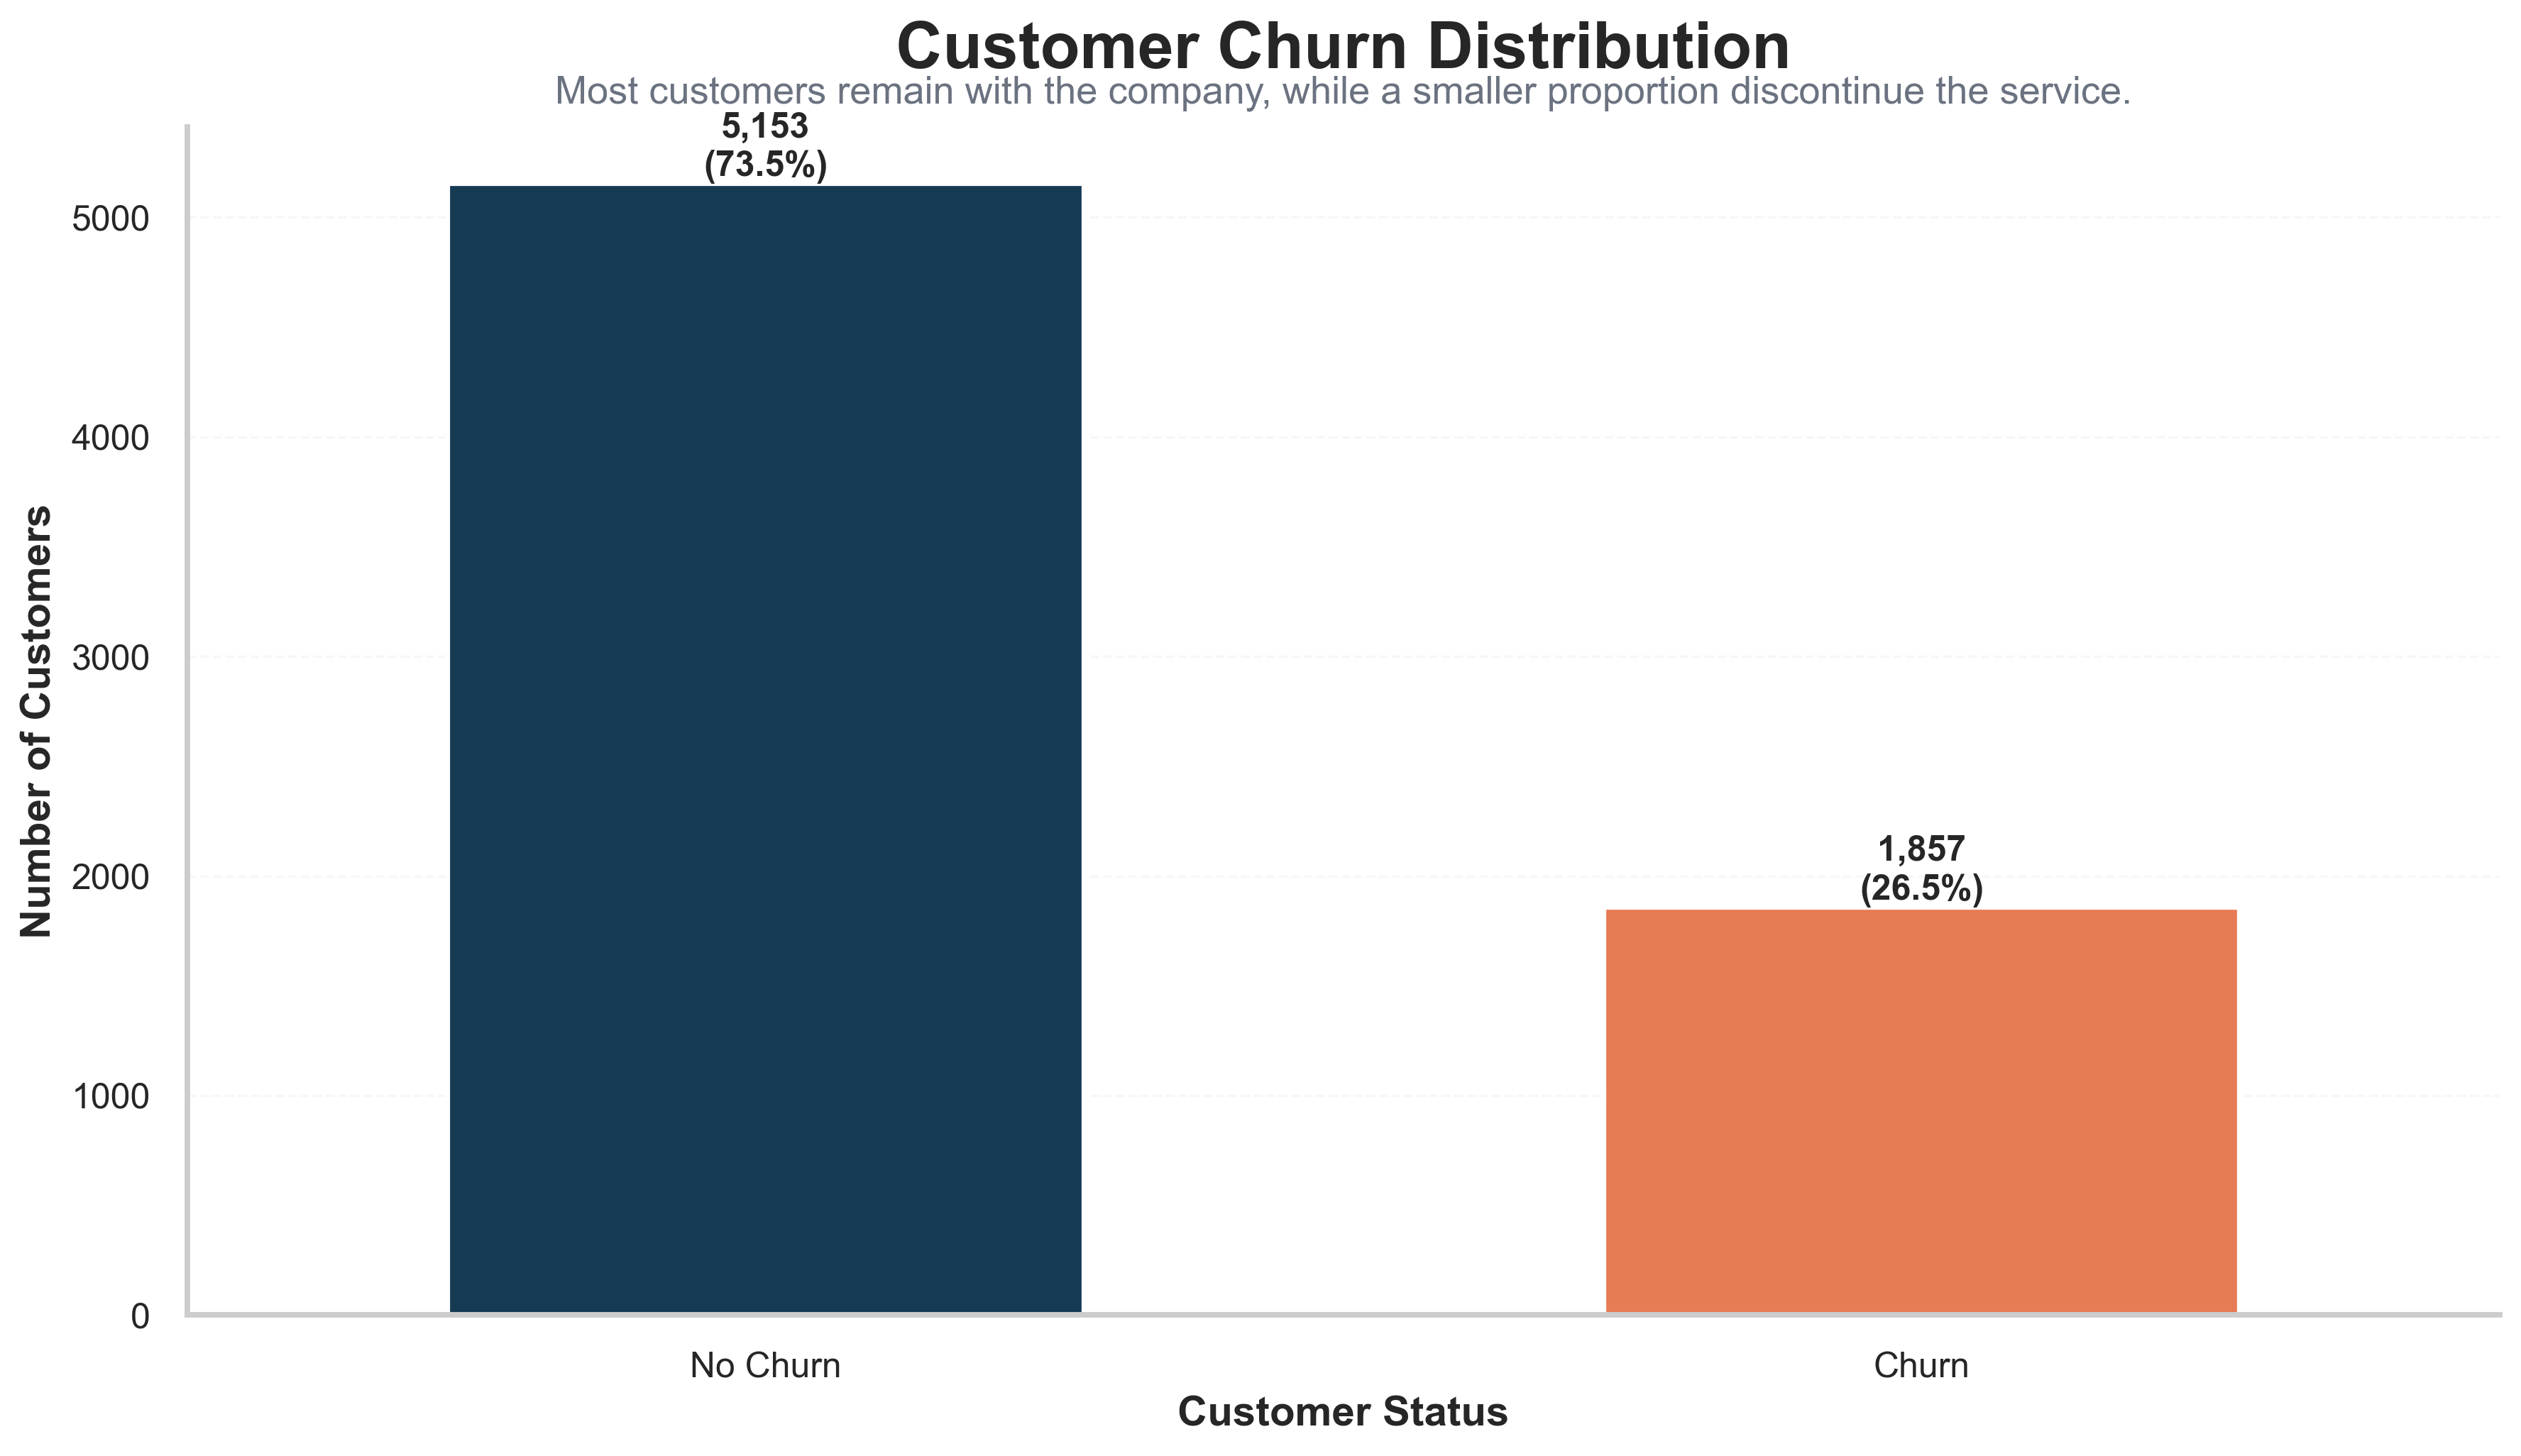

In [186]:
# Visualize customer churn distribution

plt.figure(figsize=(12, 7))

# Create count plot
ax = sns.countplot(
    x="Churn_Yes",
    data=df,
    palette=["#0B3C5D", "#FF6F3C"],  # Midnight Blue, Burnt Orange
    width=0.55
)

# Total customers
total = len(df)

# Add count and percentage labels
for p in ax.patches:

    count = int(p.get_height())
    percentage = count / total * 100

    ax.annotate(
        f"{count:,}\n({percentage:.1f}%)",
        (
            p.get_x() + p.get_width()/2,
            p.get_height()
        ),
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# Main title
plt.title(
    "Customer Churn Distribution",
    fontsize=22,
    fontweight="bold",
    pad=20
)

# Subtitle
plt.text(
    0.5,
    1.02,
    "Most customers remain with the company, while a smaller proportion discontinue the service.",
    transform=ax.transAxes,
    ha="center",
    fontsize=13,
    color="#6B7280"
)

# Axis labels
plt.xlabel(
    "Customer Status",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Number of Customers",
    fontsize=14,
    fontweight="bold"
)

# Rename ticks
plt.xticks(
    ticks=[0, 1],
    labels=["No Churn", "Churn"],
    fontsize=12
)

plt.yticks(fontsize=12)

# Soft horizontal grid
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.15
)

# Remove unnecessary borders
sns.despine()

# Adjust spacing
plt.tight_layout()

# Save ultra-high-resolution image
plt.savefig(
    "images/churn_distribution.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [153]:
# Calculate churn rates by contract type
month_to_month_churn = df[
    (df["Contract_One year"] == 0) &
    (df["Contract_Two year"] == 0)
]["Churn_Yes"].mean() * 100

one_year_churn = df[
    df["Contract_One year"] == 1
]["Churn_Yes"].mean() * 100

two_year_churn = df[
    df["Contract_Two year"] == 1
]["Churn_Yes"].mean() * 100

In [154]:
print(f"Month-to-Month Contract Churn Rate: {month_to_month_churn:.2f}%")
print(f"One Year Contract Churn Rate: {one_year_churn:.2f}%")
print(f"Two Year Contract Churn Rate: {two_year_churn:.2f}%")

Month-to-Month Contract Churn Rate: 42.64%
One Year Contract Churn Rate: 11.28%
Two Year Contract Churn Rate: 2.85%


C:\Users\Aizen Yagami\AppData\Local\Temp\ipykernel_5812\2059980986.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


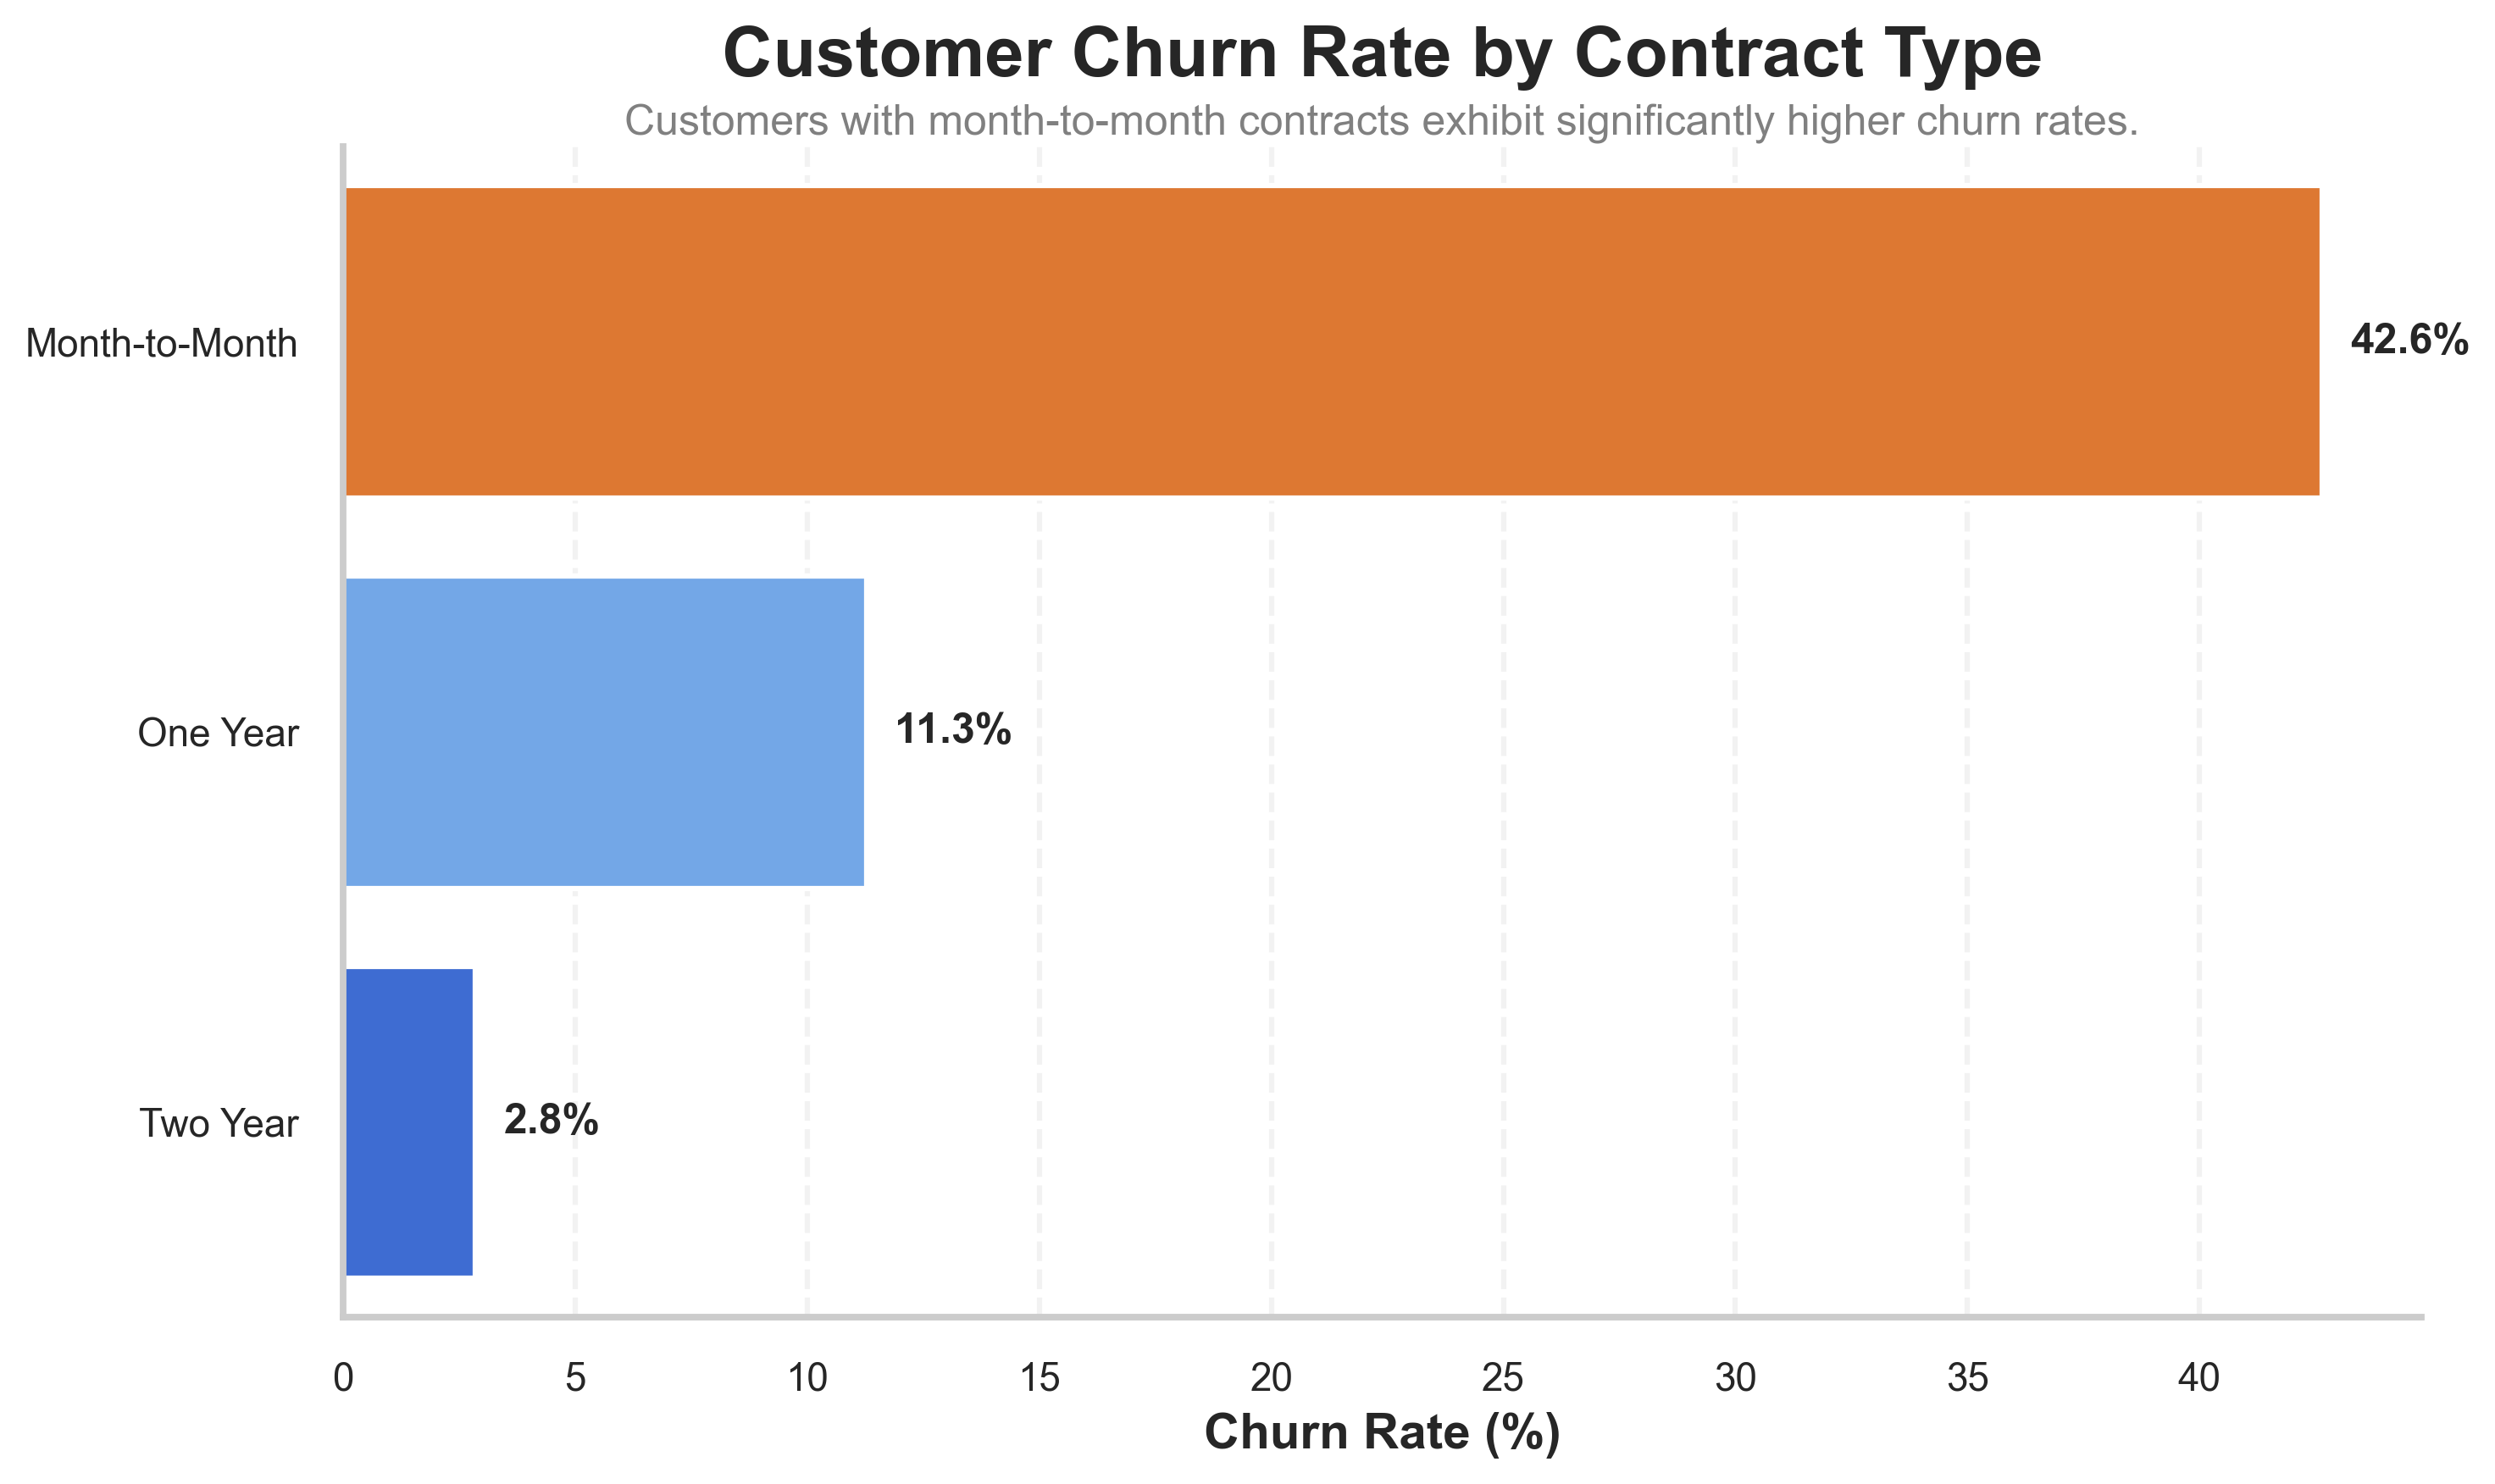

In [179]:
# Create a dataframe for visualization
contract_churn = pd.DataFrame({
    "Contract Type": [
        "Month-to-Month",
        "One Year",
        "Two Year"
    ],
    "Churn Rate": [
        month_to_month_churn,
        one_year_churn,
        two_year_churn
    ]
})

# Sort for better visual storytelling
contract_churn = contract_churn.sort_values(
    by="Churn Rate",
    ascending=False
)

# Create figure
plt.figure(figsize=(10, 6))

# Create horizontal barplot
ax = sns.barplot(
    data=contract_churn,
    y="Contract Type",
    x="Churn Rate",
    palette=["#F97316", "#60A5FA", "#2563EB"]
)

# Add percentage labels
for p in ax.patches:
    width = p.get_width()

    ax.annotate(
        f"{width:.1f}%",
        (
            width,
            p.get_y() + p.get_height()/2
        ),
        fontsize=12,
        fontweight="bold",
        va="center",
        xytext=(8,0),
        textcoords="offset points"
    )

# Title
plt.title(
    "Customer Churn Rate by Contract Type",
    fontsize=20,
    fontweight="bold",
    pad=20
)

# Subtitle
plt.text(
    0.5,
    1.01,
    "Customers with month-to-month contracts exhibit significantly higher churn rates.",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="gray"
)

# Labels
plt.xlabel(
    "Churn Rate (%)",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "",
    fontsize=14
)

# Grid
plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

# Remove unnecessary borders
sns.despine()

# Improve spacing
plt.tight_layout()

# Save high quality image
plt.savefig(
    "images/churn_rate_by_contract.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Observation

Customers with month-to-month contracts exhibit the highest churn rate (42.64%), while customers with two-year contracts exhibit the lowest churn rate (2.85%). Long-term contracts are associated with better customer retention.

#### 4.3 Does Monthly Charges impact churn?

C:\Users\Aizen Yagami\AppData\Local\Temp\ipykernel_5812\2757180610.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


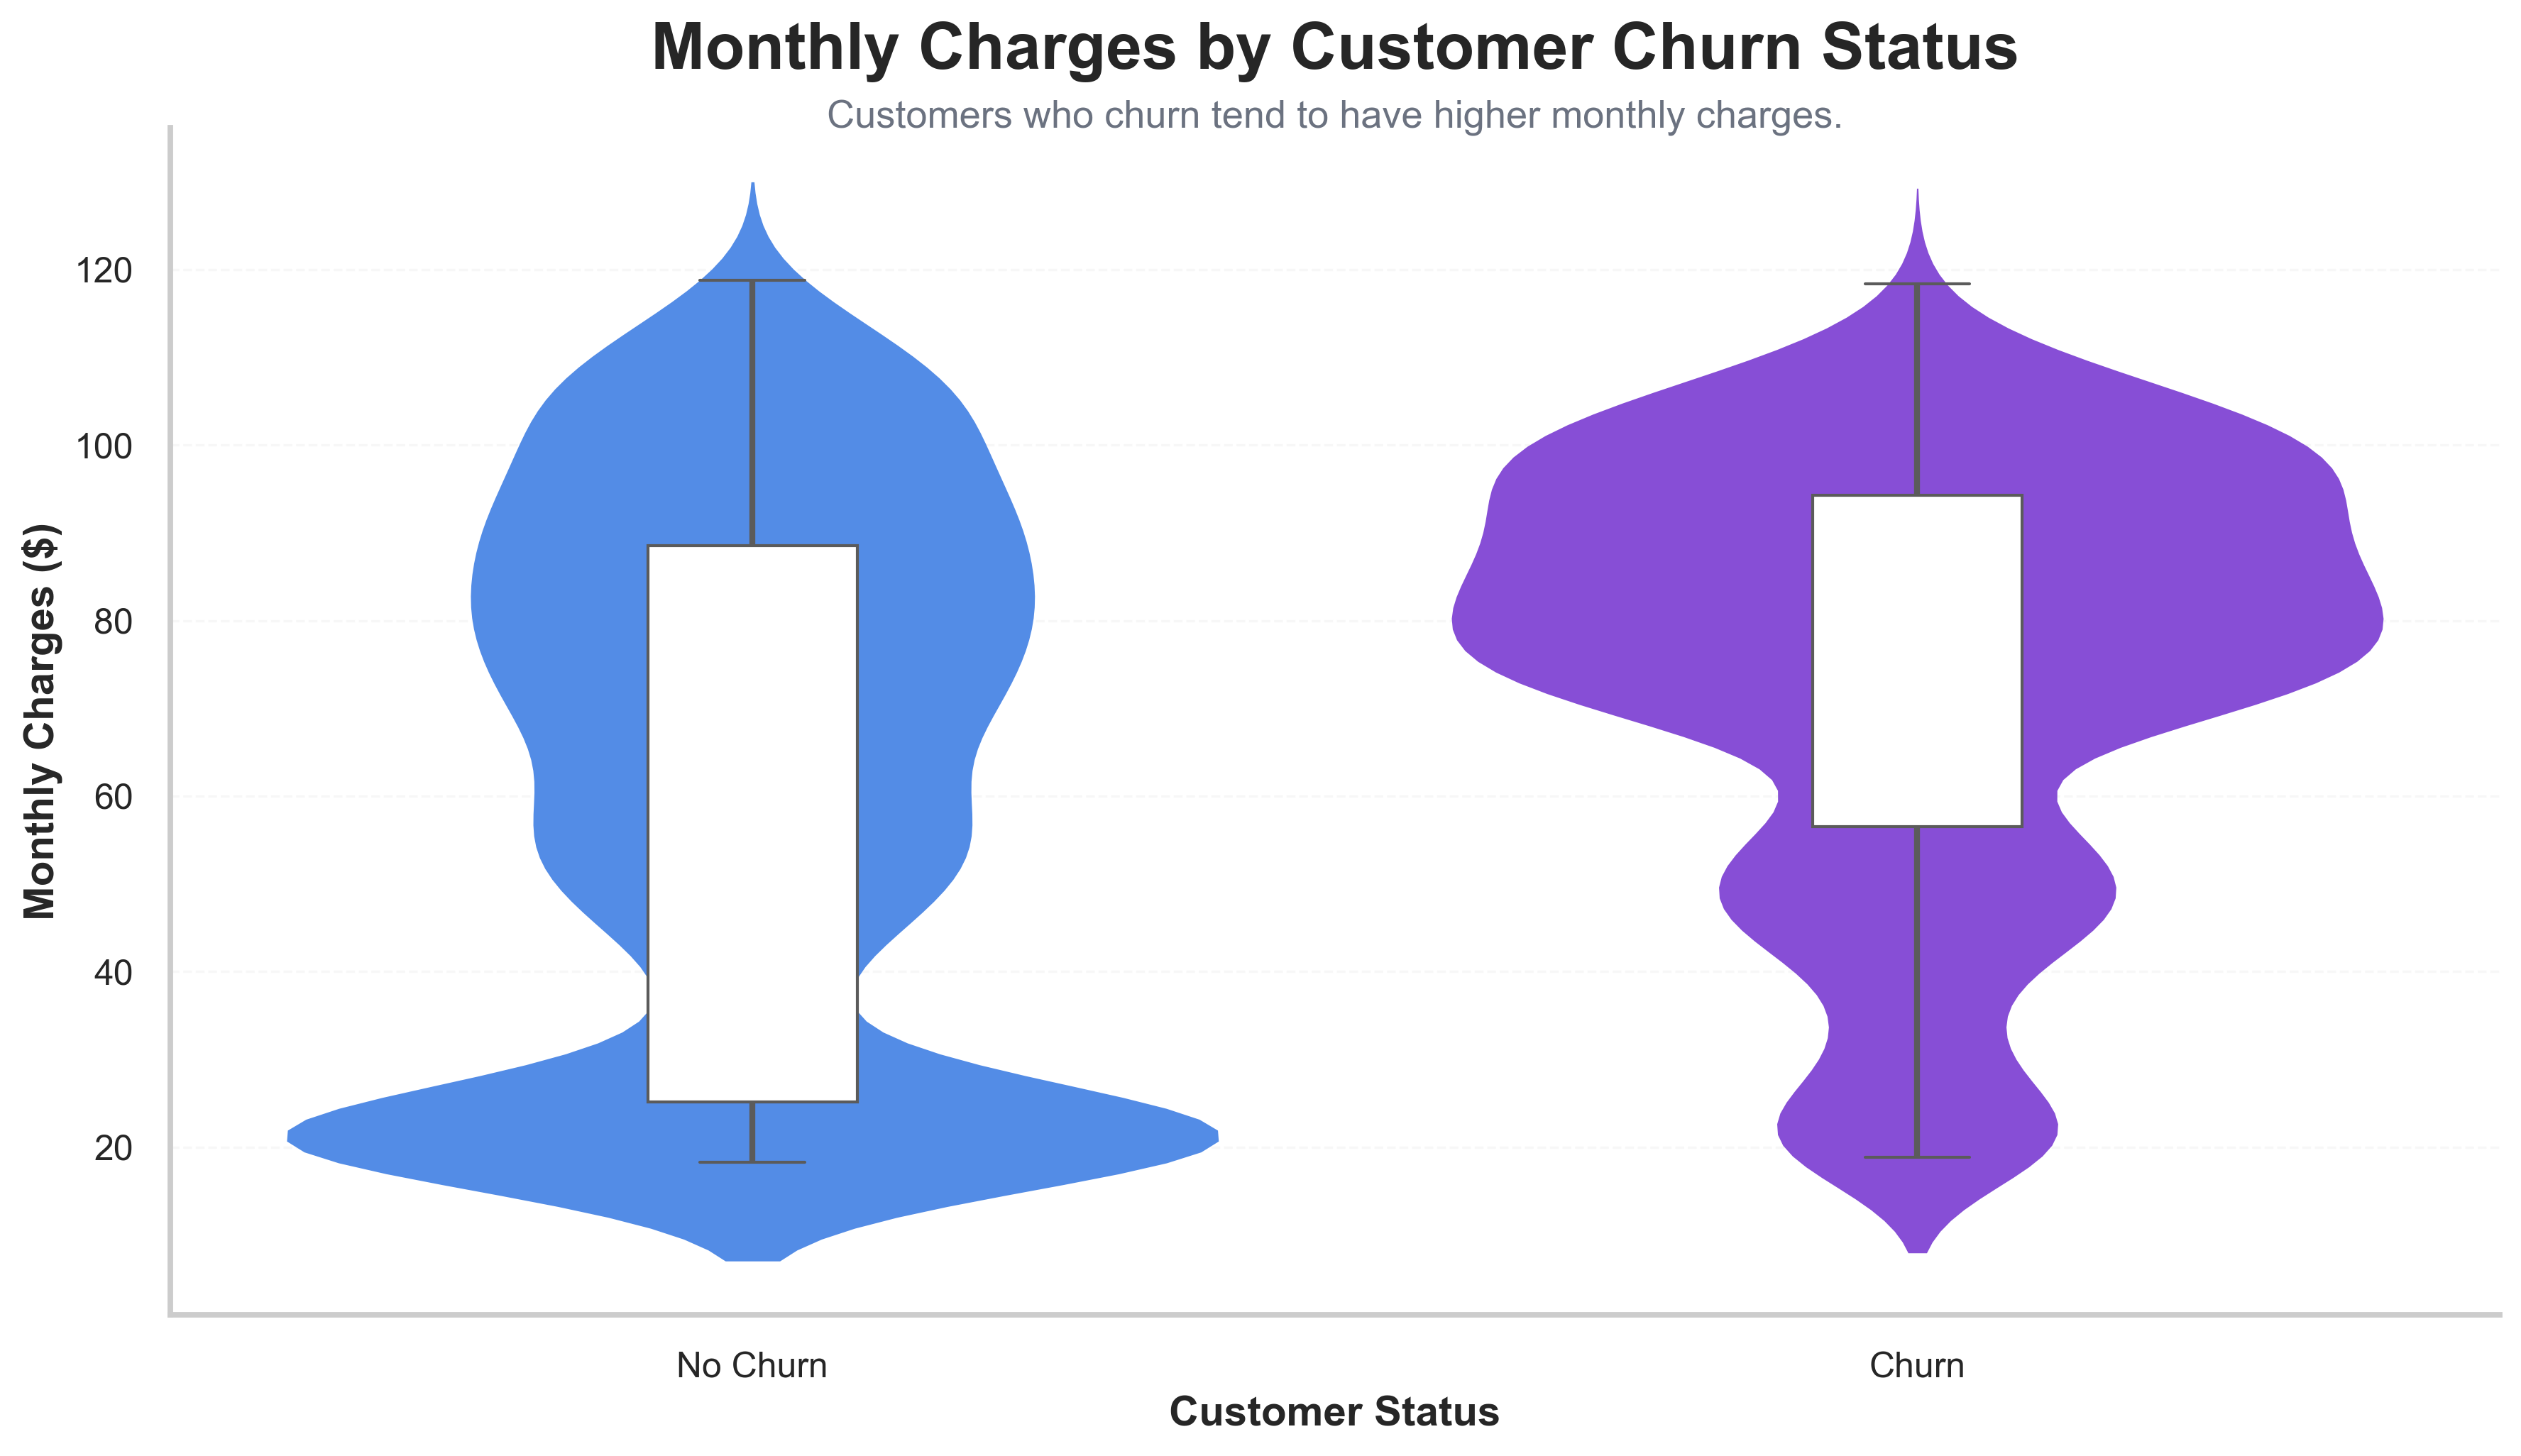

In [188]:
# Visualize Monthly Charges by Churn Status

plt.figure(figsize=(12, 7))

# Violin plot (distribution)
sns.violinplot(
    x="Churn_Yes",
    y="MonthlyCharges",
    data=df,
    palette=["#3A86FF", "#8338EC"],  # Royal Blue, Purple
    inner=None,
    linewidth=0
)

# Boxplot overlay
sns.boxplot(
    x="Churn_Yes",
    y="MonthlyCharges",
    data=df,
    width=0.18,
    showcaps=True,
    boxprops={"facecolor":"white", "zorder":3},
    whiskerprops={"linewidth":2},
    medianprops={"color":"red", "linewidth":2},
    showfliers=False
)

# Title
plt.title(
    "Monthly Charges by Customer Churn Status",
    fontsize=22,
    fontweight="bold",
    pad=20
)

# Subtitle
plt.text(
    0.5,
    1.00,
    "Customers who churn tend to have higher monthly charges.",
    transform=plt.gca().transAxes,
    ha="center",
    fontsize=13,
    color="#6B7280"
)

# Labels
plt.xlabel(
    "Customer Status",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Monthly Charges ($)",
    fontsize=14,
    fontweight="bold"
)

# Rename ticks
plt.xticks(
    ticks=[0, 1],
    labels=["No Churn", "Churn"],
    fontsize=12
)

plt.yticks(fontsize=12)

# Soft grid
plt.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.15
)

# Remove unnecessary borders
sns.despine()

# Layout
plt.tight_layout()

# Save ultra-high-quality image
plt.savefig(
    "images/monthly_charges_vs_churn.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

### 4.4 Which features correlate most with churn?

In [157]:
# Calculate feature correlations with churn
churn_corr = df.corr()["Churn_Yes"].sort_values(ascending=False)

# Display correlations
print(churn_corr)

Churn_Yes                                1.000000
InternetService_Fiber optic              0.307612
PaymentMethod_Electronic check           0.301079
MonthlyCharges                           0.194008
PaperlessBilling_Yes                     0.190518
SeniorCitizen                            0.151270
StreamingTV_Yes                          0.065058
StreamingMovies_Yes                      0.062670
MultipleLines_Yes                        0.041888
PhoneService_Yes                         0.011072
gender_Male                             -0.008694
MultipleLines_No phone service          -0.011072
DeviceProtection_Yes                    -0.064978
OnlineBackup_Yes                        -0.081145
PaymentMethod_Mailed check              -0.091649
PaymentMethod_Credit card (automatic)   -0.134052
Partner_Yes                             -0.148670
Dependents_Yes                          -0.162366
TechSupport_Yes                         -0.163980
OnlineSecurity_Yes                      -0.170565


##### Top 10 Correlated Features

In [158]:
# Display top 10 correlations with churn
print(churn_corr.head(10))

Churn_Yes                         1.000000
InternetService_Fiber optic       0.307612
PaymentMethod_Electronic check    0.301079
MonthlyCharges                    0.194008
PaperlessBilling_Yes              0.190518
SeniorCitizen                     0.151270
StreamingTV_Yes                   0.065058
StreamingMovies_Yes               0.062670
MultipleLines_Yes                 0.041888
PhoneService_Yes                  0.011072
Name: Churn_Yes, dtype: float64


#### Bottom 10 Correlations

In [159]:
# Display bottom 10 correlations with churn
print(churn_corr.tail(10))

TotalCharges                           -0.198362
OnlineSecurity_No internet service     -0.228220
StreamingMovies_No internet service    -0.228220
OnlineBackup_No internet service       -0.228220
InternetService_No                     -0.228220
TechSupport_No internet service        -0.228220
DeviceProtection_No internet service   -0.228220
StreamingTV_No internet service        -0.228220
Contract_Two year                      -0.301375
tenure                                 -0.353339
Name: Churn_Yes, dtype: float64


#### Correlation Heatmap

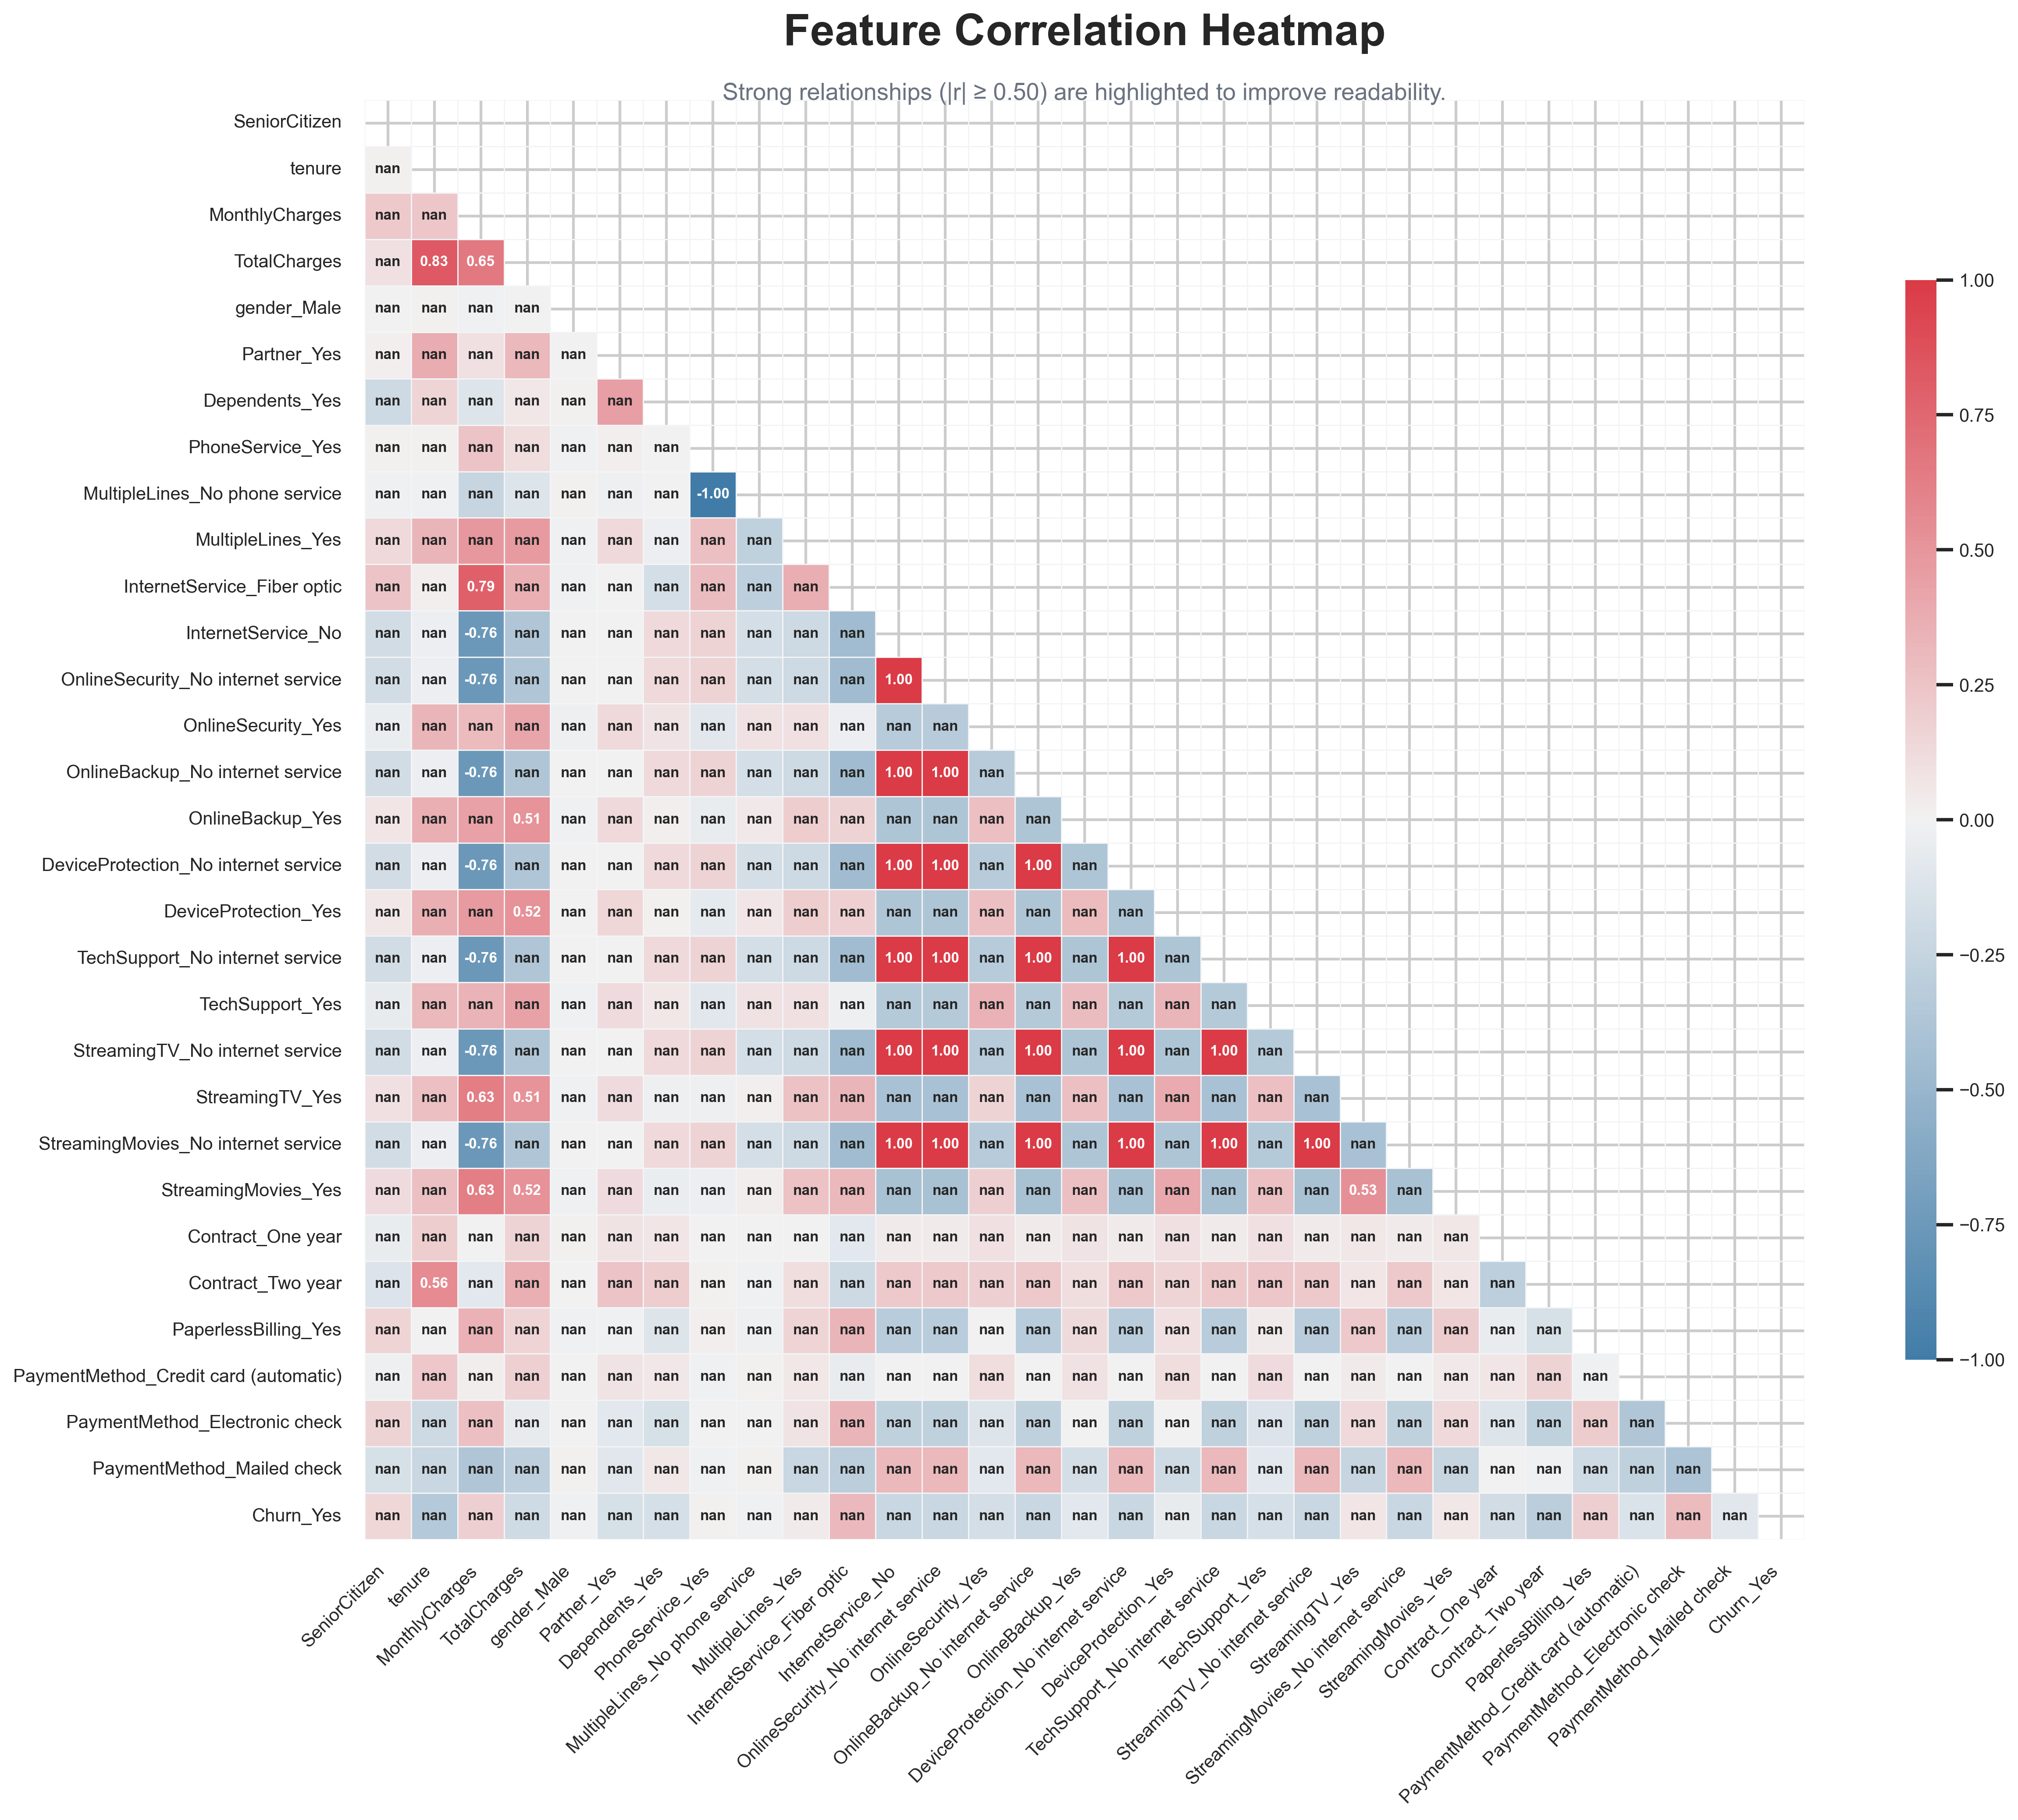

In [191]:
# Calculate correlation matrix
corr_matrix = df.corr().round(2)

# Create upper triangle mask
mask = np.triu(
    np.ones_like(
        corr_matrix,
        dtype=bool
    )
)

# Show annotations only for strong correlations
annot_matrix = corr_matrix.copy()

annot_matrix[
    corr_matrix.abs() < 0.50
] = np.nan

# Create figure
plt.figure(
    figsize=(18, 14),
    facecolor="white"
)

# Premium light diverging colormap
cmap = sns.diverging_palette(
    240,      # Blue
    10,       # Red
    as_cmap=True
)

# Draw heatmap
ax = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    center=0,
    square=True,
    linewidths=0.25,
    linecolor="#F3F4F6",

    # Annotate only strong correlations
    annot=annot_matrix,
    fmt=".2f",
    annot_kws={
        "fontsize":8,
        "fontweight":"bold"
    },

    # Color bar
    cbar_kws={
        "shrink":0.75,
        "aspect":35
    }
)

# Title
plt.title(
    "Feature Correlation Heatmap",
    fontsize=24,
    fontweight="bold",
    pad=30
)

# Subtitle
plt.text(
    0.5,
    1.00,
    "Strong relationships (|r| ≥ 0.50) are highlighted to improve readability.",
    transform=ax.transAxes,
    ha="center",
    fontsize=13,
    color="#6B7280"
)

# Tick styling
plt.xticks(
    fontsize=10,
    rotation=45,
    ha="right"
)

plt.yticks(
    fontsize=10,
    rotation=0
)

# Improve colorbar appearance
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(
    labelsize=10
)

# Tight layout
plt.tight_layout()

# Save ultra-high-quality image
plt.savefig(
    "images/feature_correlation.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

### Observations
##### Typical findings are:
- "Customers with longer tenure are less likely to churn."
- "Customers with two-year contracts have lower churn."
- "Higher monthly charges are associated with higher churn"
- "Fiber optic internet users tend to exhibit higher churn."
                         

## 5. Feature Selection

In [161]:
# Separate features and target variable
X = df.drop("Churn_Yes", axis=1)

# Define target variable
y = df["Churn_Yes"]

## 6. Train-Test Split

In [162]:
# Import required libraries for model building
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Import machine learning models

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [163]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Scale features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Train the models on Scaled data

In [164]:
# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

# Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

# XGBoost
xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

## 11. Model Evaluation

In [165]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

### 11.1 Accuracy Score, Precision Score, Recall Score, F1 Score & Model Comparison



In [166]:
# Create model comparison dataframe
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, xgb_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ]
})

model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.823823,0.623333,0.582555,0.602254
1,Decision Tree,0.748930,0.458667,0.535826,0.494253
2,Random Forest,0.802425,0.577465,0.510903,0.542149
3,XGBoost,0.800999,0.568627,0.542056,0.555024


In [167]:
# Display models sorted by F1 Score
model_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.823823,0.623333,0.582555,0.602254
3,XGBoost,0.800999,0.568627,0.542056,0.555024
2,Random Forest,0.802425,0.577465,0.510903,0.542149
1,Decision Tree,0.748930,0.458667,0.535826,0.494253


### 11.2 Confusion Matrix

In [168]:
# Display model comparison table
model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.823823,0.623333,0.582555,0.602254
1,Decision Tree,0.748930,0.458667,0.535826,0.494253
2,Random Forest,0.802425,0.577465,0.510903,0.542149
3,XGBoost,0.800999,0.568627,0.542056,0.555024


C:\Users\Aizen Yagami\AppData\Local\Temp\ipykernel_5812\168241173.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


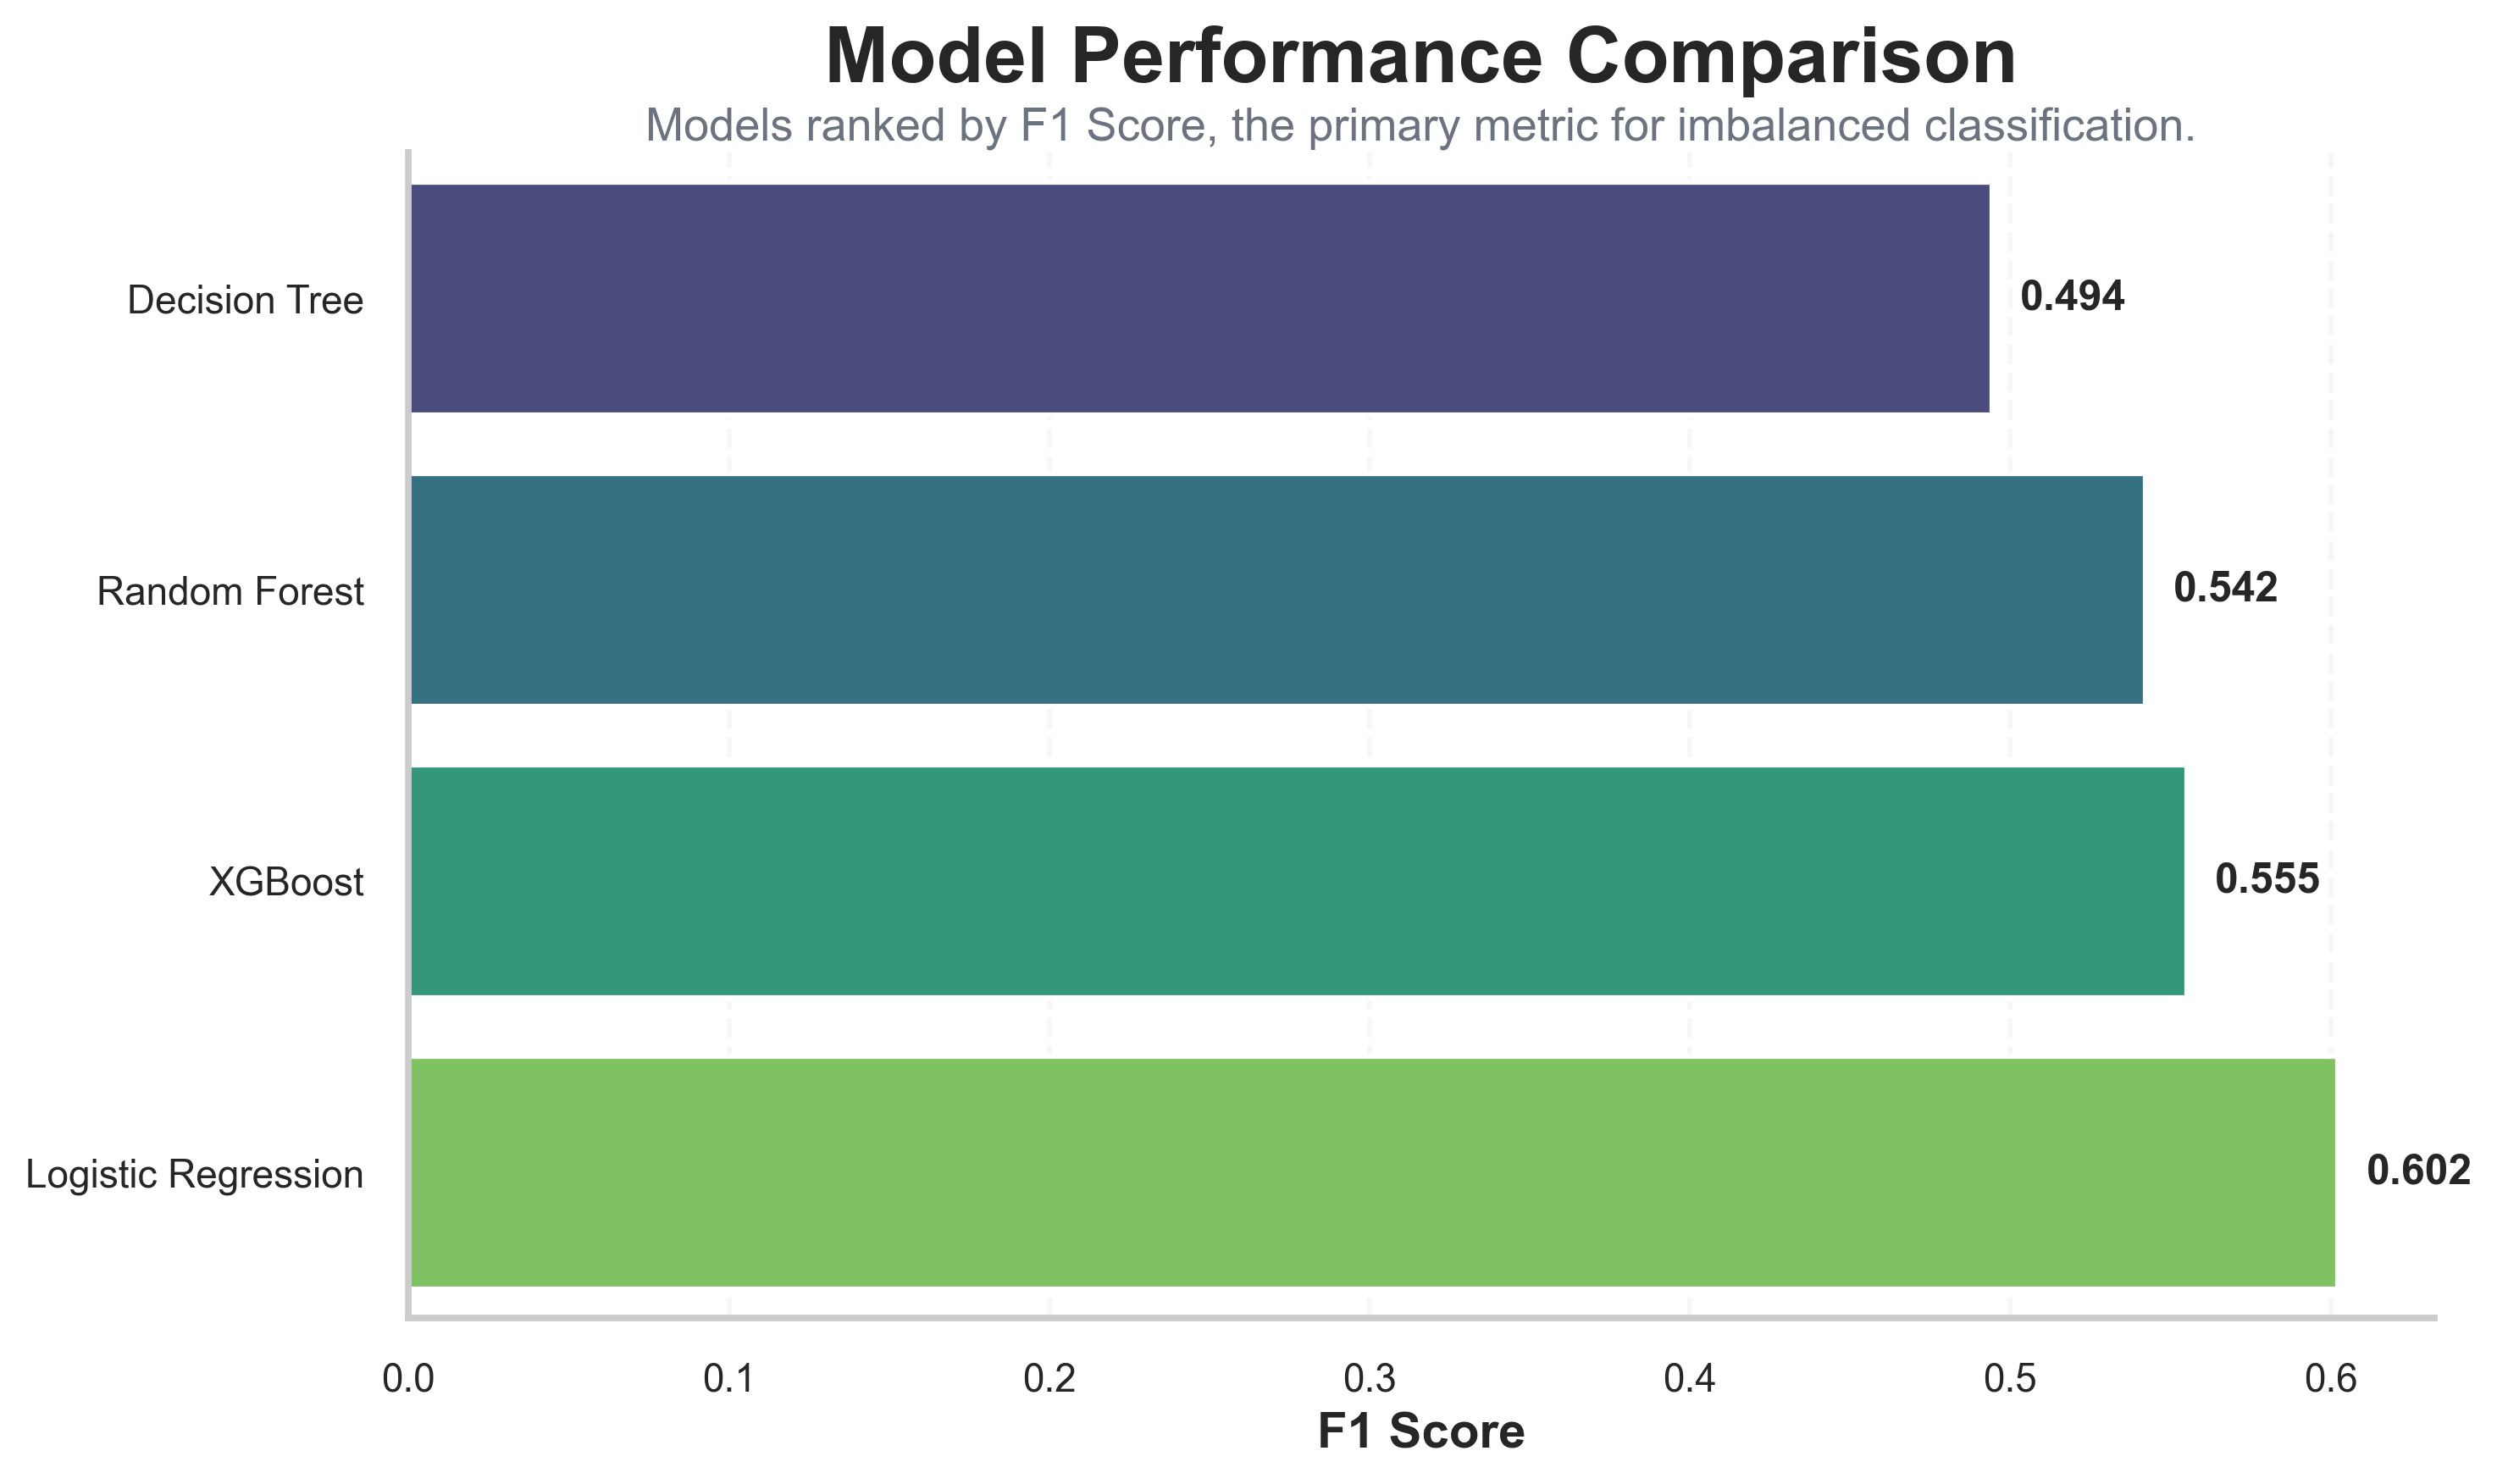

In [195]:
# Sort models by F1 Score
sorted_results = model_results.sort_values(
    by="F1 Score",
    ascending=True
)

# Create figure
plt.figure(
    figsize=(10, 6),
    facecolor="white"
)

# Plot
ax = sns.barplot(
    data=sorted_results,
    y="Model",
    x="F1 Score",
    palette="viridis"
)

# Add score labels
for p in ax.patches:

    width = p.get_width()

    ax.annotate(
        f"{width:.3f}",
        (
            width,
            p.get_y() + p.get_height()/2
        ),
        fontsize=12,
        fontweight="bold",
        va="center",
        xytext=(8,0),
        textcoords="offset points"
    )

# Title
plt.title(
    "Model Performance Comparison",
    fontsize=22,
    fontweight="bold",
    pad=20
)

# Subtitle
plt.text(
    0.5,
    1.01,
    "Models ranked by F1 Score, the primary metric for imbalanced classification.",
    transform=ax.transAxes,
    ha="center",
    fontsize=13,
    color="#6B7280"
)

plt.xlabel(
    "F1 Score",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel("")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.15
)

sns.despine()

plt.tight_layout()

plt.savefig(
    "images/model_comparison.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [169]:
# Generate confusion matrix
cm = confusion_matrix(y_test, rf_pred)

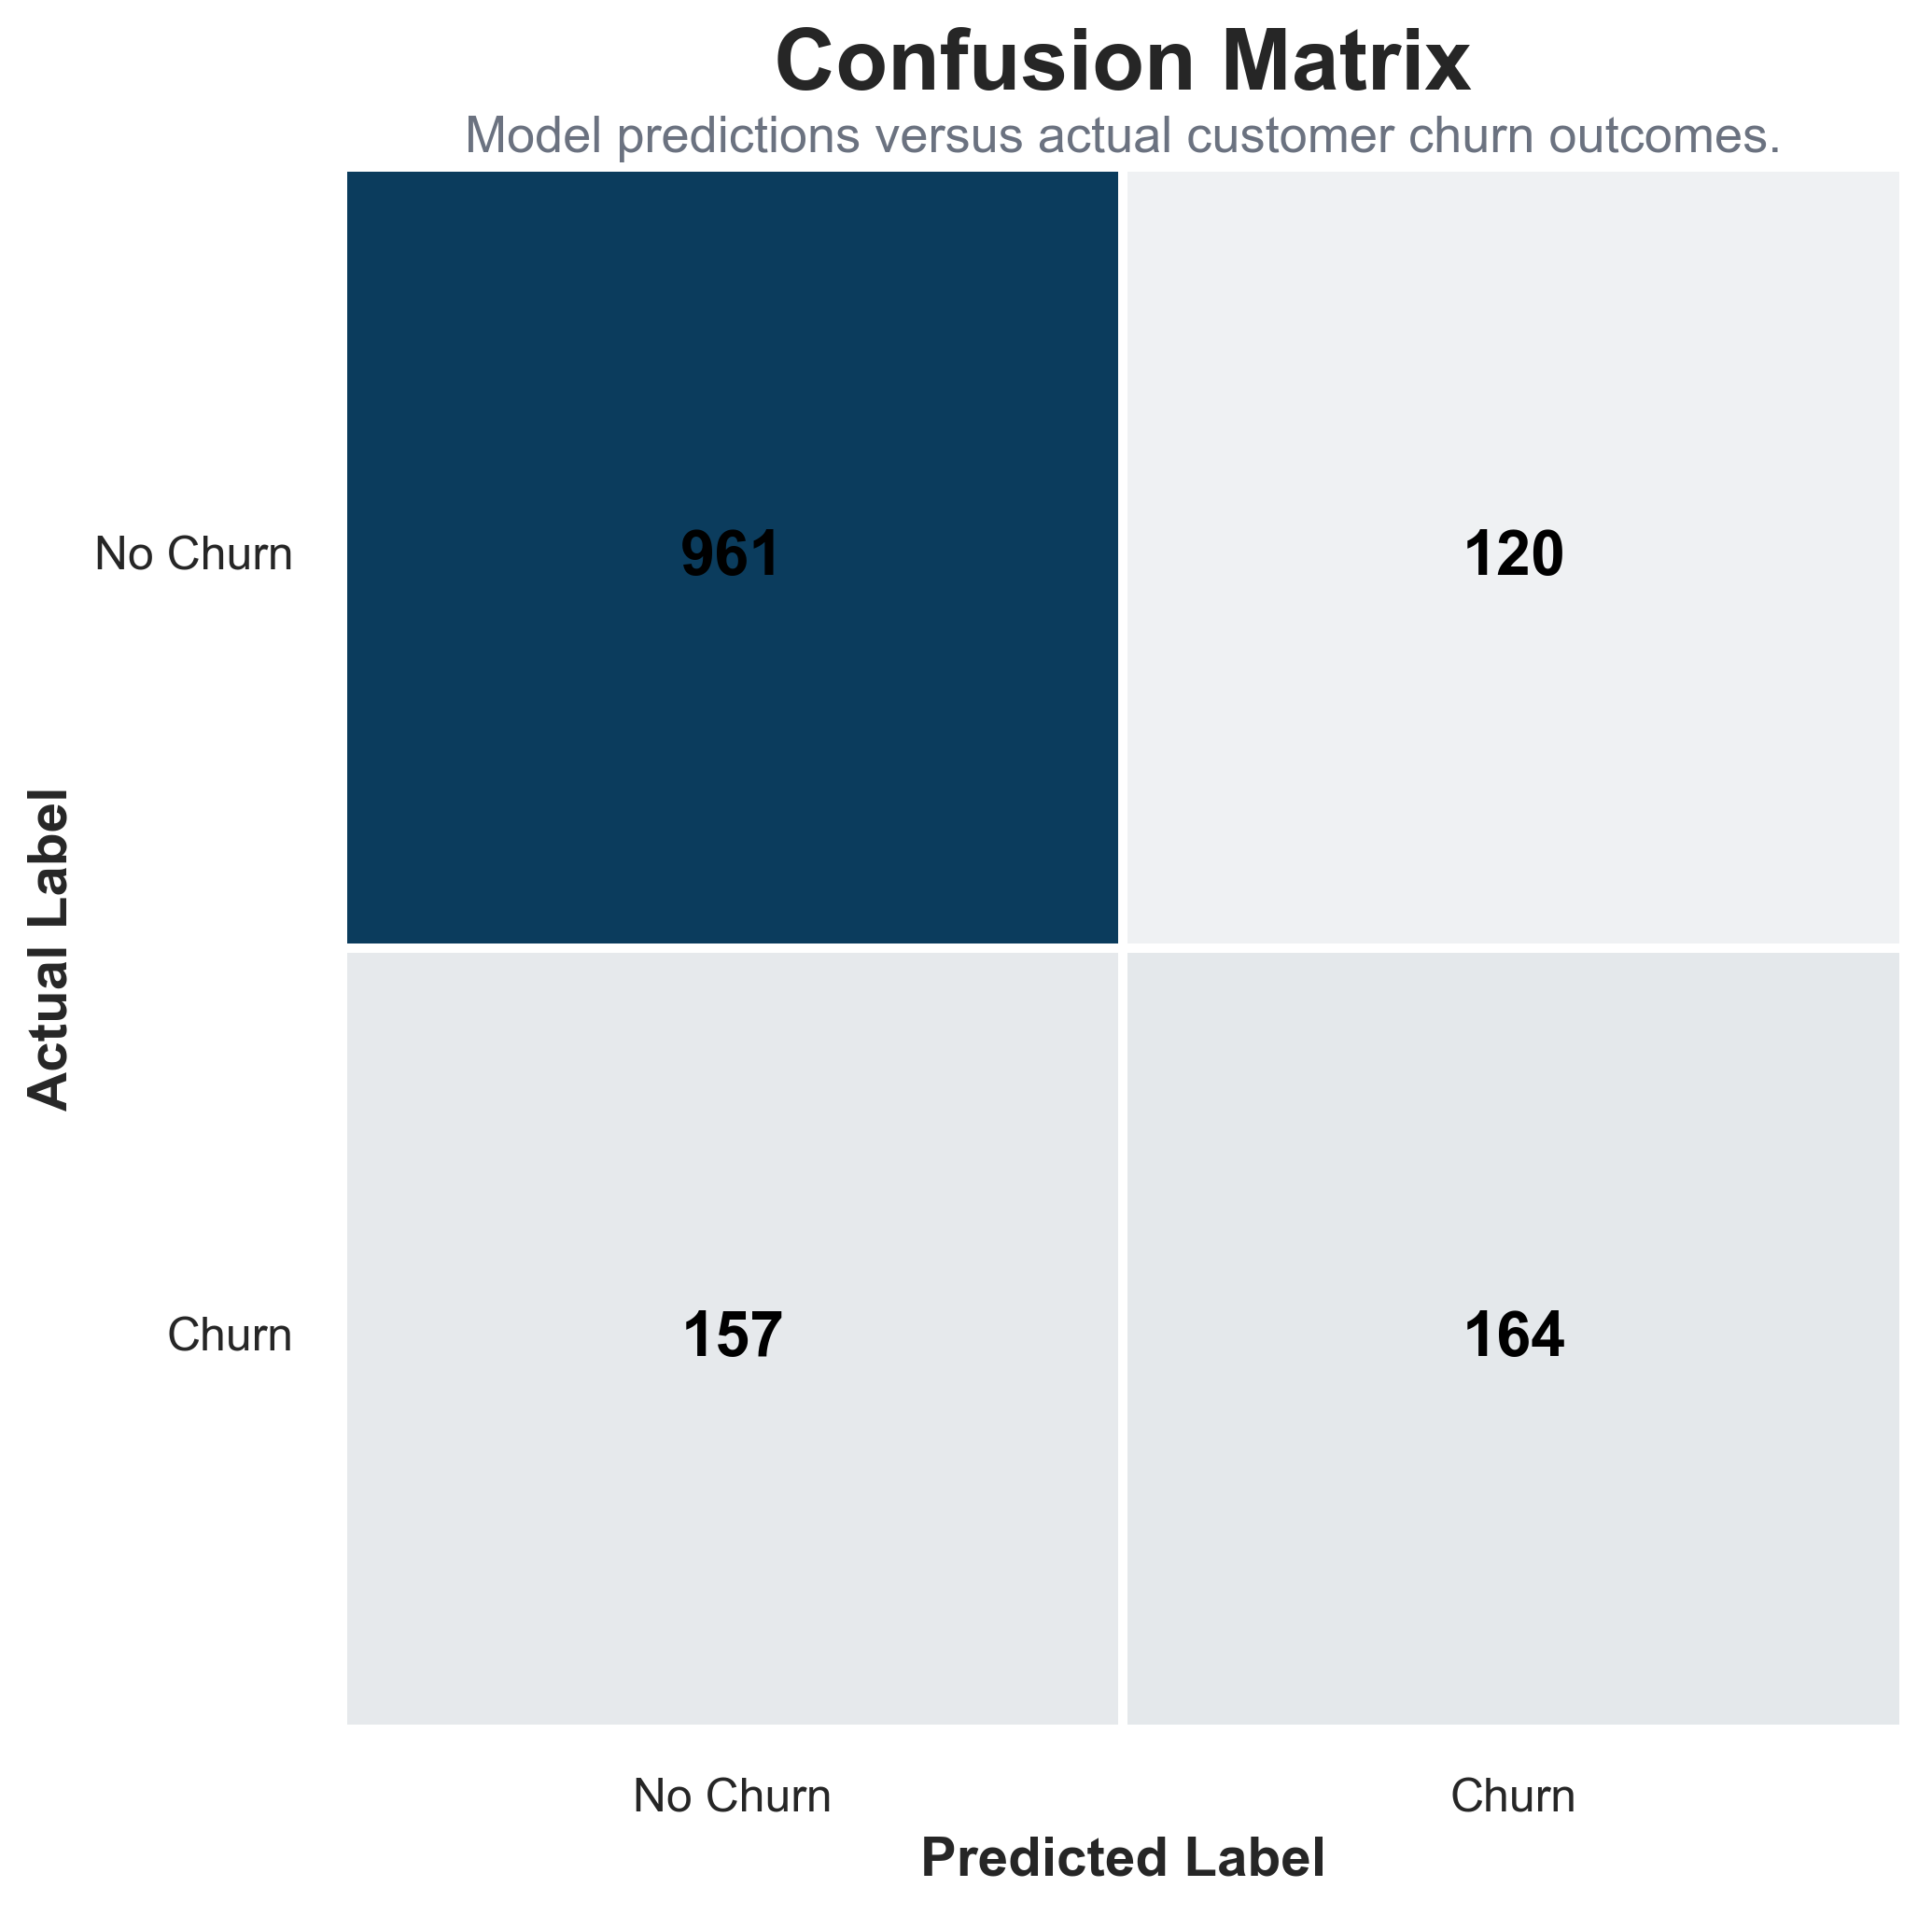

In [193]:
# Create figure
plt.figure(
    figsize=(8, 7),
    facecolor="white"
)

# Premium colormap
cmap = sns.light_palette(
    "#0B3C5D",
    as_cmap=True
)

# Draw heatmap
ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap=cmap,
    linewidths=2,
    linecolor="white",
    square=True,
    cbar=False,

    annot_kws={
        "fontsize":16,
        "fontweight":"bold",
        "color":"black"
    }
)

# Title
plt.title(
    "Confusion Matrix",
    fontsize=22,
    fontweight="bold",
    pad=20
)

# Subtitle
plt.text(
    0.5,
    1.01,
    "Model predictions versus actual customer churn outcomes.",
    transform=ax.transAxes,
    ha="center",
    fontsize=13,
    color="#6B7280"
)

# Axis labels
plt.xlabel(
    "Predicted Label",
    fontsize=14,
    fontweight="bold"
)

plt.ylabel(
    "Actual Label",
    fontsize=14,
    fontweight="bold"
)

# Tick labels
plt.xticks(
    ticks=[0.5, 1.5],
    labels=["No Churn", "Churn"],
    fontsize=12
)

plt.yticks(
    ticks=[0.5, 1.5],
    labels=["No Churn", "Churn"],
    fontsize=12,
    rotation=0
)

# Remove outer border
sns.despine(left=True, bottom=True)

# Improve spacing
plt.tight_layout()

# Save ultra-high-quality image
plt.savefig(
    "images/confusion_matrix.png",
    dpi=600,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

## 12. Business Recommendations
 1. Customers with month-to-month contracts exhibit significantly higher churn rates. Promoting long-term contracts may improve retention.

 2. Customers with higher monthly charges are more likely to churn. Personalized pricing and loyalty programs can help reduce attrition.
 
 3. Customers with longer tenure demonstrate lower churn rates. Enhancing customer onboarding and early engagement may strengthen retention.

## 13. Conclusion

 - In this project, Logistic Regression, Decision Tree, and Random Forest models were developed to predict customer churn. The models achieved satisfactory performance and identified key factors influencing customer attrition, including contract type, monthly charges, and tenure. These insights can assist telecom companies in implementing effective customer retention strategies.